In [1]:
%load_ext autoreload
%autoreload 2
import os,sys
import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
device = 'cuda:5'

In [4]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")

gene_list_df = pd.read_csv('data/mouse_geneset/Rodriguez-Fraticelli_HSC_gene_signatures.csv', skiprows=1).iloc[:,:17]
gene_list_df = gene_list_df.fillna('')

raw_ad = adata.raw.to_adata()
score_names = []
for sig in ['Low-output_Rodriguez_et_al', 'High-output_Rodriguez_et_al']:

    score_name = sig.replace("_Rodriguez_et_al", " score").replace("-", " ")
    gene_sig = [g for g in gene_list_df[sig].values if g != '']
    overlap = np.intersect1d(gene_sig, raw_ad.var_names)

    print(sig, len(gene_sig),len(overlap))
    sc.tl.score_genes(adata, overlap, score_name=score_name)

    score_names.append(score_name)


Low-output_Rodriguez_et_al 1513 1369
High-output_Rodriguez_et_al 1455 1296


In [5]:
gene_list_df.columns

Index(['Low-output_Rodriguez_et_al', 'High-output_Rodriguez_et_al',
       'Multilineage_Rodriguez_et_al', 'Mk-bias_Rodriguez_et_al',
       'Serial-engraftment_Rodriguez_et_al', 'Stemscore_Giladi_et_al',
       'RACFP_DIM_Lauridsen_et_al', 'SuMO_Wilson_et_al', 'MolO_Wilson_et_al',
       'HSC_vs_MPP4_Cabezas-Wallscheid_et_al',
       'dHSC_vs_aHSC_Cabezas-Wallscheid_et_al', 'HSC_Pietras_et_al',
       'HSC1 cluster', 'HSC2 cluster', 'HSC3 cluster', 'HSC4 cluster',
       'dHSC_aHSC_single-cell_Cabezas-Wallscheid_et_al'],
      dtype='object')

In [6]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [7]:
adata.obs.anno_man.cat.categories

Index(['Bas/MC prog', 'Eos', 'Ery', 'HSC', 'Int prog', 'Ly', 'Meg',
       'Mono/DC prog', 'Neu'],
      dtype='object')

In [8]:
cellstate_key = "DM_scaled"
n_dimension = 10
base_cellstate = adata.obsm[cellstate_key][:,:n_dimension].copy()

In [9]:
Dataset = reader.TwoTimpepoint_AnnDS(
                    AnnData=adata, 
                    timepoint_idx=9, 
                    n_dimension=10,
                    cellstate_key=cellstate_key,  #'DM_EigenVector'
                    log_transform=False,
                    norm_time=False,
                    deltax_key=None,
                    batchsize= 100)

Computing density :
`density_funs` not specified, use gaussian kde


# load model

In [10]:
model_ckpt = "logs/tom_pos-DM_scaled_n9/pde_params_tsense/lightning_logs/version_0/checkpoints/epoch=257-total_loss=0.76506275.ckpt"
model_ckpt = "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=87-total_loss=1.34044445.ckpt"
pde_model = models.pde_params.load_from_checkpoint(model_ckpt)

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


<Axes: title={'center': 'anno_man'}, xlabel='UMAP1', ylabel='UMAP2'>

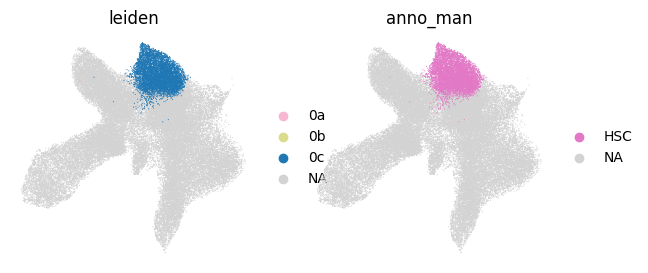

In [11]:
fig, axs = plt.subplots(1,2, figsize=(7,3))
sc.pl.umap(adata, color='leiden', groups=['0a', '0b', '0c'], ax=axs[0], show=False, frameon=False)
sc.pl.umap(adata, color='anno_man', groups='HSC', ax=axs[1], show=False, frameon=False)

# go for all HSC cells

In [12]:
n_interval = 10
ncell = 100

In [13]:
from torch import nn
import gc
import torch.nn.functional as F

In [14]:
pde_model = pde_model.to(device)

In [15]:
from PINN.models import Density_Transfer

In [16]:
DT = Density_Transfer(pde_model)

In [15]:
from tqdm.auto import tqdm

In [31]:
# initial cell
n_interval = 10
ncell = 90

timepoint_tx_days = sorted(adata.obs.timepoint_tx_days.unique())
t0 = timepoint_tx_days[0]

Tmaps = {}
Tmaps_norm = {}
S_traj_lookup = {}
HSC_cbs = []

for it,t in tqdm(enumerate(timepoint_tx_days[:-1])):
    # if it==0:
    #     torch.cuda.memory._record_memory_history()

    integrate_time = np.linspace(t/t0, timepoint_tx_days[it+1]/t0 ,n_interval+1) / pde_model.time_scale_factor
    print(integrate_time)

    # find cell of time
    start_cell = adata.obs.query("`anno_man` == 'HSC' & `timepoint_tx_days` == @t").index
    start_cell = list(start_cell)
    HSC_cbs.append(start_cell)

    # define initital density and cellstates
    cell_index = [np.where(adata.obs_names == x)[0].item() for x in start_cell]
    u0 = Dataset.u_b[it, cell_index].float().to(device)
    s0 = torch.from_numpy(Dataset.cellstate[cell_index]).float().to(device)

    S_trajectory = DT.cellstate_drift(s0, integrate_time)
    Tmaps_t, Tmaps_t_norm = DT.transition_by_batch(s0, u0, integrate_time, n_interval=n_interval, ncell=ncell)

    del u0, s0
    
    S_traj_lookup[str(t)] = S_trajectory
    Tmaps_norm[str(t)] = Tmaps_t_norm
    Tmaps[str(t)] = Tmaps_t

0it [00:00, ?it/s]

[0.2        0.22666667 0.25333333 0.28       0.30666667 0.33333333
 0.36       0.38666667 0.41333333 0.44       0.46666667]
[0.46666667 0.5        0.53333333 0.56666667 0.6        0.63333333
 0.66666667 0.7        0.73333333 0.76666667 0.8       ]
[0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8]
[1.8        1.94666667 2.09333333 2.24       2.38666667 2.53333333
 2.68       2.82666667 2.97333333 3.12       3.26666667]
[3.26666667 3.44666667 3.62666667 3.80666667 3.98666667 4.16666667
 4.34666667 4.52666667 4.70666667 4.88666667 5.06666667]
[5.06666667 5.30666667 5.54666667 5.78666667 6.02666667 6.26666667
 6.50666667 6.74666667 6.98666667 7.22666667 7.46666667]
[ 7.46666667  7.79333333  8.12        8.44666667  8.77333333  9.1
  9.42666667  9.75333333 10.08       10.40666667 10.73333333]
[10.73333333 11.45333333 12.17333333 12.89333333 13.61333333 14.33333333
 15.05333333 15.77333333 16.49333333 17.21333333 17.93333333]


# resume

In [11]:
##
# v4 , constant time interval = 3

# np.save("results/tompos_Tmap/Cellstate_traj_tplus3_v4.npy", S_traj_lookup)
# np.save("results/tompos_Tmap/Tmaps_norm_tplus3_v4.npy", Tmaps_norm)
# np.save("results/tompos_Tmap/Tmaps_TM1_tplus3_v4.npy", Tmaps)

# S_traj_lookup = np.load("results/tompos_Tmap/Cellstate_traj_tplus3_v4.npy", allow_pickle=True).item()
# Tmaps_norm = np.load("results/tompos_Tmap/Tmaps_norm_tplus3_v4.npy", allow_pickle=True).item()
# Tmaps = np.load("results/tompos_Tmap/Tmaps_TM1_tplus3_v4.npy", allow_pickle=True).item()

## 
# v4 , interval by pop t
# np.save("results/tompos_Tmap/Cellstate_traj_TM1_v4.npy", S_traj_lookup)
# np.save("results/tompos_Tmap/Tmaps_norm_TM1_v4.npy", Tmaps_norm)
# np.save("results/tompos_Tmap/Tmaps_TM1_v4.npy", Tmaps)

S_traj_lookup = np.load("results/tompos_Tmap/Cellstate_traj_TM1_v4.npy", allow_pickle=True).item()
Tmaps_norm = np.load("results/tompos_Tmap/Tmaps_norm_TM1_v4.npy", allow_pickle=True).item()
Tmaps = np.load("results/tompos_Tmap/Tmaps_TM1_v4.npy", allow_pickle=True).item()

##
# v0
# version_0/checkpoints/epoch=257-total_loss=0.76506275.ckpt
# np.save("results/tompos_Tmap/Tmaps_norm.npy", Tmaps_norm)
# np.save("results/tompos_Tmap/Tmaps_left.npy", Tmaps)

# S_traj_lookup = np.load("results/tompos_Tmap/Cellstate_v0.npy", allow_pickle=True).item()
# Tmaps_norm = np.load("results/tompos_Tmap/Tmaps_norm.npy", allow_pickle=True).item()
# Tmaps = np.load("results/tompos_Tmap/Tmaps_left.npy", allow_pickle=True).item()

In [12]:
Tmaps = np.load("results/tompos_Tmap/Tmaps_TM1_v4_by_time.npy", allow_pickle=True).item()
Tmaps_norm = np.load("results/tompos_Tmap/Tmaps_norm_TM1_v4_by_time.npy", allow_pickle=True).item()

In [13]:
for k, v in Tmaps_norm.items():
    print('time', k, v.shape)

time 3 (394, 10, 10)
time 7 (633, 10, 10)
time 12 (613, 10, 10)
time 27 (3357, 10, 10)
time 49 (4444, 10, 10)
time 76 (5184, 10, 10)
time 112 (11323, 10, 10)
time 161 (6947, 10, 10)


In [14]:
celltype_cbs = []
for t in adata.uns['pop']['t']:
    start_cell = adata.obs.query(f"`timepoint_tx_days` == @t").index
    celltype_cbs.append( list(start_cell))

reordered_ad = adata[np.concatenate(celltype_cbs)]

In [15]:
all_Tmap_norm = list(Tmaps_norm.values()) + [np.zeros((len(celltype_cbs[-1]), 10, 10))]
all_Tmap_norm = np.concatenate(all_Tmap_norm, axis=0)

all_Tmap = list(Tmaps.values()) + [np.zeros((len(celltype_cbs[-1]), 10, 10))]
all_Tmap = np.concatenate(all_Tmap, axis=0)

In [16]:
reordered_ad.obsm['Tmap'] = all_Tmap.reshape(adata.shape[0],-1)
reordered_ad.obsm['Tmap_norm'] = all_Tmap_norm.reshape(adata.shape[0],-1)

In [17]:
adata = reordered_ad[adata.obs_names]

In [18]:
adata

View of AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_c

In [19]:
from PINN.functions import eval_funs as ef

In [20]:
def plot_transport_map_example(Tmaps, n_example=2, log=False, kws={}):

    fig, axs = plt.subplots(n_example, 8, figsize=(12,n_example*1.5+1), **kws)

    i = 0
    for t, tmap in Tmaps.items():
        tmap = tmap
        tmap_nz = tmap[tmap.sum(axis=1).sum(axis=1)!=0]
        
        for j in range(n_example):
            
            seed = np.random.randint(0,tmap_nz.shape[0])
            t_show = tmap_nz[seed]
            
            if log:
                t_show =  np.log(t_show+1e-30)
            
            # set upper triangle to nan
            trui = np.triu_indices_from(t_show, k=1)
            t_show[trui] = np.nan
            
            axs[j, i].matshow(t_show)
            axs[j,i].set_xticklabels('')
            axs[j,i].set_yticklabels('')

        axs[0,i].set_title(t)
        i+=1

    for j in range(n_example):
        axs[j,0].set_ylabel('cells')
        
    axs[n_example-1,3].set_xlabel("  "*10+'trajectories')

    return fig, axs

In [21]:
nz_tmap = adata[np.where(adata.obsm['Tmap_norm'].sum(axis=1) > 0)[0]]
nz_tmap

View of AnnData object with n_obs × n_vars = 31120 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_c

In [22]:
import seaborn as sns

In [23]:
from matplotlib import cm

In [24]:
n_interval = 10
dpi = 60
# cmap = sns.light_palette(sns.color_palette('Blues')[-1], as_cmap=True)
cmap = sns.color_palette('Blues', n_colors=20, as_cmap=True)
# cmap = 'Blues'


Tmap_ct_t = {}
cbs_t = {}

# ct_of_interest = ['HSC', 'Int prog', 'Meg/Ery prog']
ct_of_interest = ['HSC']
for ct in ct_of_interest:
    if ct == 'Eos prog':
        continue
    cb_t = []
    Tmap_ct = []

    for t in nz_tmap.uns['pop']['t'][:-1]:

        cbs = nz_tmap.obs.query("`fine_anno` ==@ct & `timepoint_tx_days`== @t").index

        # fill in nan matrix as place holder
        if len(cbs) == 0:
            Tmap_ct.append(np.zeros(n_interval**2,))
        else:
            # randome choose 1 matrix
            tm_choiced = nz_tmap[np.random.choice(cbs)].obsm['Tmap']
            Tmap_ct.append(tm_choiced.copy())

        cb_t.append(list(cbs))
    

    Tmap_ct_t[ct] = Tmap_ct
    cbs_t[ct] = cb_t

In [25]:
from PINN.plotting_fns import density_plot as dp

In [26]:
test_T = Tmap_ct_t['HSC'][1]
test_T[np.logical_and(test_T!=0, ~np.isnan( test_T))]

array([3.91827734e-06, 7.99786994e-06, 1.21470739e-05, 1.63470377e-05,
       2.04517473e-05, 2.42805036e-05, 2.81034481e-05, 3.21038970e-05,
       3.63538638e-05, 4.06791769e-05])

In [27]:
Tmap_ct_t['HSC'][1][np.tril_indices_from(Tmap_ct_t['HSC'][1])]

array([3.91827734e-06])

In [ ]:
from PINN.plotting_fns import density_plot as dp

ct = 'HSC' 
nrow = 2
ncol = len(Tmap_ct_t[ct]) // 2

fig, axs = plt.subplots(nrow, ncol, figsize=(2.5*ncol, 2.5*nrow), dpi=600, 
                        frameon=False, gridspec_kw={"hspace":0.5, 'wspace':0.3})
axs = axs.flatten()


for it, T in enumerate(Tmap_ct_t[ct]):

    T_values = T[np.logical_and(T!=0, ~np.isnan( T))]
    

    dp.plot_tmap(T, ax=axs[ it], log=True, 
                 vmax=np.log(T_values.max()), vmin=np.log(T_values.min()/5))

    t = adata.uns['pop']['t'][it]
    tp1 = adata.uns['pop']['t'][it+1]

    axs[it].set_title(f"{t}  " + r"$\rightarrow$" + f"  {tp1}", fontsize=16)

    axs[it].set_yticks(np.arange(0,10,2))
    axs[it].set_yticklabels([r"$t_1$", r"$t_3$", r"$t_5$", r"$t_7$", r"$t_9$"])
    
    axs[it].tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)
    axs[it].set_xticks(np.arange(0,10,2))
    axs[it].set_xticklabels([r"$s_1$", r"$s_3$", r"$s_5$", r"$s_7$", r"$s_9$"])



In [64]:
fig.savefig("figures/fig5_example_HSC_tmap.pdf", transparent=True, format='pdf')

In [ ]:
fig, axs = plt.subplots(1, 8, figsize=(8,8))

i = 0
for t, tmap in Tmaps.items():

    tmap_nz = tmap[tmap.sum(axis=1).sum(axis=1)!=0]

    axs[i].matshow(np.log(tmap_nz[:40,-1,:]+1e-10))
    axs[i].set_title(t)
    axs[i].set_xticklabels('')
    axs[i].set_yticklabels('')
    i+=1

axs[0].set_ylabel('cells')
axs[3].set_xlabel("  "*10+'trajectories')

In [26]:
# np.save("results/tompos_Tmap/Tmap_by_u_ratio.npy", Tmaps)

# clustering

In [28]:
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

def hierarchical_clustering_sklearn(matrix, num_clusters, linkage='ward'):
    """
    Perform hierarchical clustering on the rows of a matrix using sklearn and return the clustered row indices.

    Parameters:
    - matrix: numpy array, the input matrix where rows are to be clustered.
    - num_clusters: int, the number of clusters to form (truncation level).
    - linkage: str, the linkage method to use (default is 'ward').

    Returns:
    - clustered_indices: list of lists, where each sublist contains the row indices of a cluster.
    """
    # Perform hierarchical clustering using AgglomerativeClustering
    clustering = AgglomerativeClustering(n_clusters=num_clusters, linkage=linkage)
    clusters = clustering.fit_predict(matrix)
    
    # Organize row indices by cluster
    clustered_indices = [[] for _ in range(num_clusters)]
    for row_index, cluster_id in enumerate(clusters):
        clustered_indices[cluster_id].append(row_index)
    
    return clustered_indices, clusters

# resume

In [29]:
old_ad = sc.read_h5ad("data/tom_pos_old.h5ad")

In [30]:
S_traj_lookup = np.load("results/tompos_Tmap/Cellstate_traj_TM1_v4.npy", allow_pickle=True).item()
Tmaps_norm = np.load("results/tompos_Tmap/Tmaps_norm_TM1_v4_HSC.npy", allow_pickle=True).item()
Tmaps = np.load("results/tompos_Tmap/Tmaps_TM1_v4_HSC.npy", allow_pickle=True).item()


HSC_cbs = []
for t in old_ad.uns['pop']['t']:
    cbs = old_ad.obs.query("`anno_man`=='HSC' & `timepoint_tx_days` == @t").index
    HSC_cbs.append(list(cbs))

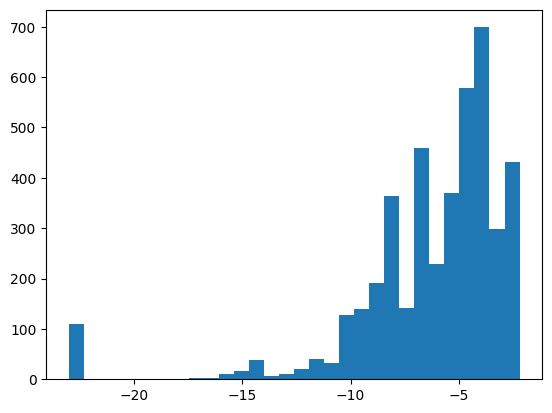

In [31]:
Tmap_all = np.concatenate(list(Tmaps.values()), axis=0)
plt.hist(np.log(Tmap_all[:,-1].sum(axis=1)+1e-10),bins=30);

In [59]:
Tmap_all_flat = np.transpose(Tmap_all, axes=[0,2,1]).reshape(-1,100) # switch to Tmaps_norm
nz_id = np.where(Tmap_all_flat.sum(axis=1)!=0)[0]
Tmap_all_flat[nz_id] = Tmap_all_flat[nz_id] / Tmap_all_flat[nz_id].sum(axis=1,keepdims=True)

In [ ]:
from PINN.plotting_fns import param_plot as pp

cluster_colors = ["#6F71A3",
"#7C8DBE",
"#C5D9ED",
"#FFF5D4",
"#FFE7BD",
"#F0AD8E",
"#BA7590",
"#A1689E"]

In [78]:
cluster_colors = sns.color_palette('Set3')

In [61]:

indices = np.arange(100)
x_coords = indices // 10  # Row index in original matrix
y_coords = indices % 10   # Column index in original matrix

# Normalize coordinates to [0, 1]
norm_x = (x_coords - x_coords.min()) / (x_coords.ptp() if x_coords.ptp() != 0 else 1)
norm_y = (y_coords - y_coords.min()) / (y_coords.ptp() if y_coords.ptp() != 0 else 1)


In [62]:
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.colorbar import ColorbarBase
cmap_blues = ListedColormap(plt.cm.Blues(np.linspace(0.15, 0.9, 11)))
cmap_grey = ListedColormap(plt.cm.Greys_r(np.linspace(0.15, 0.9, 11)))


In [63]:
col_colorbar_tick_labels_x = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_y = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]

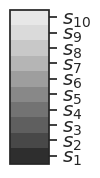

In [64]:
fig, ax = plt.subplots(1,1,figsize=(0.5,2))
cb_col_y = ColorbarBase(
        ax,
        cmap=cmap_grey,
        boundaries=np.arange(10+1)/10 - 0.05,
        ticks=np.arange(10),
        orientation='vertical'
    )
cb_col_y.set_ticks(np.arange(10)/10)
cb_col_y.set_ticklabels(col_colorbar_tick_labels_x)

In [65]:
Tmap_all_flat.shape

(4321, 100)

In [66]:
np.concatenate(HSC_cbs[:3]).shape

(409,)

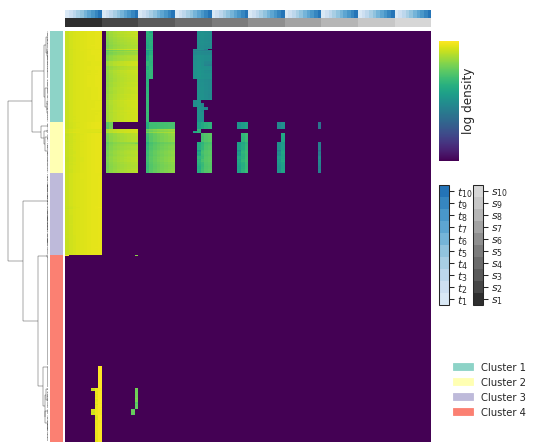

Cluster assignments: [ 4  4  4 ... 10 10  8]
Reordered row indices: [780, 783, 241, 796, 753, 768, 799, 800, 366, 683, 332, 371, 762, 786, 771, 795, 547, 591, 620, 625, 200, 641, 648, 675, 81, 408, 536, 130, 460, 803, 806]


In [90]:
num_clusters = 4
log = True

col_colorbar_tick_labels_y = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_x = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]


if log:
    Tmap_Matrix_early = np.log(Tmap_all_flat[:409]+1e-20)
else:
    Tmap_Matrix_early = Tmap_all_flat[:409]

sns.set_theme(font_scale=1.2, style='ticks')

cluster_flat_early, reordered_indices, g = pp.truncated_clustermap(Tmap_Matrix_early, 
            num_clusters,original_shape = (10,10),
            truncate_mode="level", p=4, 
            cluster_colors=cluster_colors, show_log=False,
            context_kws = {"figure.dpi":60},
            col_colorbar_size=(0.02, 0.25), 
            col_colorbar_location_x = (0.93, 0.35), 
            col_colorbar_location_y = (1., 0.35), 
            col_colorbar_tick_labels_x=col_colorbar_tick_labels_x,
            col_colorbar_tick_labels_y=col_colorbar_tick_labels_y,
            cbar_kws = {'label':'log density', 'ticks':[]}
            )

print("Cluster assignments:", cluster_flat)
print("Reordered row indices:", reordered_indices)

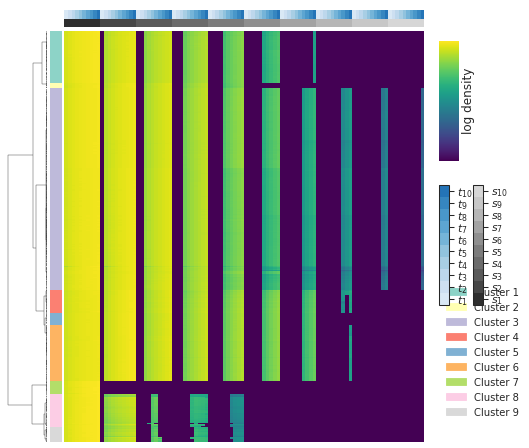

Cluster assignments: [4 4 4 ... 5 5 5]
Reordered row indices: [7487, 7726, 7657, 7746, 236, 7518, 7654, 7769, 7781, 7789, 7803, 7764, 7772, 7590, 7792, 459, 6337, 7296, 7246, 7509, 7787, 7795, 7804, 7806, 7788, 7801, 7744, 7749]


In [80]:
num_clusters = 9
log = True

col_colorbar_tick_labels_y = [r"$s_1$", r"$s_2$", r"$s_3$", r"$s_4$", r"$s_5$", r"$s_6$", r"$s_7$", r"$s_8$", r"$s_9$", r"$s_{10}$"]
col_colorbar_tick_labels_x = [r"$t_1$", r"$t_2$", r"$t_3$", r"$t_4$", r"$t_5$", r"$t_6$", r"$t_7$", r"$t_8$", r"$t_9$", r"$t_{10}$"]


if log:
    Tmap_Matrix_late = np.log(Tmap_all_flat[409:]+1e-20)
else:
    Tmap_Matrix_late = Tmap_all_flat[409:]

sns.set_theme(font_scale=1.2, style='ticks')

cluster_flat_late, reordered_indices, g = pp.truncated_clustermap(Tmap_Matrix_late, 
            num_clusters,original_shape = (10,10),
            truncate_mode="level", p=4, 
            cluster_colors=cluster_colors, show_log=False,
            context_kws = {"figure.dpi":60},
            col_colorbar_size=(0.02, 0.25), 
            col_colorbar_location_x = (0.93, 0.35), 
            col_colorbar_location_y = (1., 0.35), 
            col_colorbar_tick_labels_x=col_colorbar_tick_labels_x,
            col_colorbar_tick_labels_y=col_colorbar_tick_labels_y,
            cbar_kws = {'label':'log density', 'ticks':[]}
            )

print("Cluster assignments:", cluster_flat)
print("Reordered row indices:", reordered_indices)

In [81]:
cluster_flat_late += 4

In [82]:
np.unique(cluster_flat_late)

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13], dtype=int32)

In [83]:
print(Tmap_Matrix_late.shape)

(3912, 100)


In [ ]:
# g.savefig('figures/fig5_cluster_heatmap.svg', format='svg', transparent=True)
# g.savefig('figures/fig5_cluster_heatmap.pdf', format='pdf', transparent=True)
# g.savefig('figures/fig5_cluster_heatmap.tif', format='tif', transparent=True)

In [92]:
cluster_flat = np.concatenate([cluster_flat_early , cluster_flat_late])
adata.obs['HSC_cluster_flat'] = 'na'
named_cluster_flats = ['hsc_c%s'%c for c in cluster_flat]
adata.obs.loc[np.concatenate(HSC_cbs[:-1]), 'HSC_cluster_flat'] = named_cluster_flats


c4_cbs = adata.obs_names[adata.obs.HSC_cluster_flat == 'hsc_c4']
vwf_neg = np.intersect1d(c4_cbs,
    adata.obs_names[adata[:,'Vwf'].X.A.flatten() < 1])

vwf_plus = np.intersect1d(c4_cbs,
    adata.obs_names[adata[:,'Vwf'].X.A.flatten() >= 1])

# adata.obs.loc[vwf_neg, 'HSC_cluster_flat'] = 'hsc_c4_neg'
# adata.obs.loc[vwf_plus, 'HSC_cluster_flat'] = 'hsc_c4_plus'


Day3 = np.intersect1d(c4_cbs, adata.obs_names[adata.obs.timepoint_tx_days == 3])
Day7 = np.intersect1d(c4_cbs, adata.obs_names[adata.obs.timepoint_tx_days == 7])
Day12 = np.intersect1d(c4_cbs, adata.obs_names[adata.obs.timepoint_tx_days == 12])


# adata.obs.loc[Day3, 'HSC_cluster_flat'] = 'hsc_c4_d3'
# adata.obs.loc[Day7, 'HSC_cluster_flat'] = 'hsc_c4_d7'
# adata.obs.loc[Day12, 'HSC_cluster_flat'] = 'hsc_c4_d12'

In [ ]:
fig, axs = plt.subplots(1,1,figsize=(2,2))
sc.pl.umap(adata, size=30,color='HSC_cluster_flat',  show=False, ax=axs, frameon=False)

color_7 = ["#6F71A3", "#7C8DBE", "#C5D9ED", "#FFF5D4", "#FFE7BD", "#F0AD8E", "#F8F8F8"]
# color_7 = ["#6F71A3", "#7C8DBE", "#C5D9ED", "#FFF5D4", "#FFF5D4", "#FFF4C3", "#FFE7BD", "#F0AD8E", "#F8F8F8"]

adata.uns['HSC_cluster_flat_colors'] = color_7

fig, axs = plt.subplots(1,2,figsize=(8,3), gridspec_kw={'wspace':0.35})
sc.pl.umap(adata, size=30,color='HSC_cluster_flat', show=False, ax=axs[0], frameon=False)
sc.pl.umap(adata[adata.obs.anno_man=='HSC'], size=100,color='HSC_cluster_flat', show=False, ax=axs[1], frameon=False)

In [ ]:
HSC_ad = adata[adata.obs.anno_man=='HSC']
sc.tl.leiden(HSC_ad, resolution=2)

dpi = 60

sns.set_theme(font_scale=1.5)
fig, axs = plt.subplots(2,3,figsize=(10,7), dpi=dpi, frameon=False, gridspec_kw={"hspace":0.1, 'wspace':0})
axs = axs.flatten()

for i,t in enumerate([3,7,12,27,49,112]):

    sc.pl.umap(HSC_ad, size=30, show=False, ax=axs[i], frameon=False)
    sc.pl.umap(HSC_ad[HSC_ad.obs['timepoint_tx_days']==t], size=100,color='HSC_cluster_flat',  
               show=False, ax=axs[i], legend_loc='none', frameon=False)

    axs[i].set_title("  "+f"Day {t}")

if dpi==600:
    fig.savefig("figures/fig5_UMAP_HSC_subclass.pdf", format="pdf", transparent=True)

In [ ]:
sc.pl.umap(adata, color='data_type')

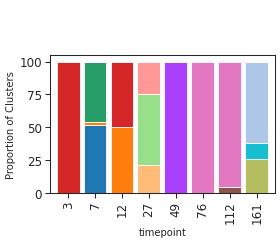

In [95]:
dpi=60
sns.set_theme(font_scale=1.3, style='ticks')
with plt.rc_context({"figure.dpi":dpi, "figure.figsize":(6,4)}):
    fig, ax = PINN.pl.obs_composition(
                adata[np.concatenate(HSC_cbs[:-1])], 
                'timepoint_tx_days', 'HSC_cluster_flat', 
                figkws={'figsize':[5,5]},
                legend_kws={"handles":[], "frameon":False,  "fontsize":13 ,'ncol':3, "bbox_to_anchor":(0.05, 1.4), "loc":'upper left', }
                )

ax.set_xlabel("timepoint", fontsize=12)
ax.set_ylabel("Proportion of Clusters", fontsize=12)

fig.show()
if dpi==600:
    fig.savefig("figures/tompos_dynamic_cluster_proportion.pdf", transparent=True)

In [130]:
adata.obs['HSC_cluster_flat'].to_csv("results/HSC_cluster_flat.csv", index=True)

In [157]:
color_palette =  dict(zip(adata.obs['HSC_cluster_flat'].cat.categories,color_7 ))

In [158]:
color_palette

{'hsc_c1': '#6F71A3',
 'hsc_c2': '#7C8DBE',
 'hsc_c3': '#C5D9ED',
 'hsc_c4': '#FFF5D4',
 'hsc_c5': '#FFE7BD',
 'hsc_c6': '#F0AD8E',
 'na': '#F8F8F8'}

In [ ]:
from matplotlib.gridspec import GridSpec
import seaborn as sns

adata.obs['timepoint'] = adata.obs['timepoint_tx_days'].astype(str)

dpi = 600

fig = plt.figure(figsize=(6,4), dpi=dpi, frameon=False)
gs = GridSpec(3,3)
ax1 = fig.add_subplot(gs[:, :])


colormap = sns.light_palette("#69d", n_colors=9, reverse=True)
sc.pl.violin(HSC_ad[HSC_ad.obs.fine_anno == 'HSC'], 
             "High output score", groupby="HSC_cluster_flat", 
             order = ['hsc_c1', 'hsc_c4', 'hsc_c3', 'hsc_c2', 'hsc_c5', 'hsc_c6'],
            #  palette=color_palette,
             ax=ax1, show=False)
sns.despine(ax=ax1)

ax1.set_ylabel("High output score")
ax1.set_xlabel("HSCs dynamic cluster")

# if dpi==600:
#     fig.savefig('figures/Lowoutput_score_HSC_violoin.pdf', format='pdf', transparent=True,pad_inches=0)

In [152]:
HSC_ad.obs['Time point'] = HSC_ad.obs['timepoint_tx_days'].astype(str)

In [ ]:

dpi = 600

fig = plt.figure(figsize=(13,4), dpi=dpi, frameon=False)
gs = GridSpec(3,3)
ax1 = fig.add_subplot(gs[:, :])

sns.violinplot(HSC_ad.obs, y="Low output score", hue="HSC_cluster_flat", 
            x = 'Time point',
            #  order = ['hsc_c1', 'hsc_c4', 'hsc_c3', 'hsc_c2', 'hsc_c5', 'hsc_c6'],
             palette=color_palette,
             ax=ax1)

sns.despine(ax=ax1)

ax1.set_ylabel("Low output score of HSCs behavior cluster")

#### separate hsc cluster 4 by time

In [ ]:

# colormap = sns.light_palette(new_palette['Meg/Ery prog'], reverse=True, n_colors=10)

fig = plt.figure(figsize=(6,4), dpi=dpi, frameon=False)
gs = GridSpec(3,3)
ax2 = fig.add_subplot(gs[:, :])

colormap = sns.light_palette("seagreen", n_colors=9)
sc.pl.violin(adata[adata.obs.fine_anno == 'Int prog'], 
"Multilineage score", groupby="timepoint", palette=colormap,show=False,
ax=ax2)
sns.despine(ax=ax2)

ax2.set_ylabel("Multi-lineage score of HSCs")
if dpi==600:
    fig.savefig('figures/Multilineage_score_HSC_violoin.pdf', format='pdf', transparent=True,pad_inches=0)

# last timepoint only

In [167]:
Tmap_all_last = Tmap_all[:,-1,:]
Tmap_all_last
nz_id = np.where(Tmap_all_last.sum(axis=1)!=0)[0]
Tmap_all_last[nz_id] = Tmap_all_last[nz_id] / Tmap_all_last[nz_id].sum(axis=1,keepdims=True)

In [ ]:
num_clusters = 9
log = False

if log:
    transfer_last = np.log(Tmap_all_last+1e-30)
else:
    transfer_last = Tmap_all_last

clusters, reordered_indices,g = PINN.pl.truncated_clustermap(transfer_last, 
                                        num_clusters, truncate_mode="level", show_log=True,
                                        p=3)

print("Cluster assignments:", clusters)
print("Reordered row indices:", reordered_indices)

In [ ]:
adata.obs['HSC_sub_clusters'] = 'na'
named_clusters = ['hsc_c%s'%c for c in clusters]
adata.obs.loc[np.concatenate(HSC_cbs[:-1]), 'HSC_sub_clusters'] = named_clusters

fig, axs = plt.subplots(1,2,figsize=(8,3), gridspec_kw={'wspace':0.35})

sc.pl.umap(adata, size=30,color='HSC_sub_clusters', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[0], frameon=False)
sc.pl.umap(adata[adata.obs.anno_man=='HSC'], size=60,color='HSC_sub_clusters', groups=['hsc_c%s'%c for c in range(1,num_clusters+1)], show=False, ax=axs[1], frameon=False)

PINN.pl.obs_composition(adata[np.concatenate(HSC_cbs)], 'timepoint_tx_days', 'HSC_sub_clusters')

In [ ]:
HSC_ad = adata[adata.obs.anno_man=='HSC']
sc.tl.leiden(HSC_ad, resolution=2)

dpi = 600

fig, axs = plt.subplots(2,3,figsize=(10,7), dpi=dpi, frameon=False, gridspec_kw={"hspace":0.1, 'wspace':0})
axs = axs.flatten()

for i,t in enumerate([3,7,12,27,49,112]):

    sc.pl.umap(HSC_ad, size=30, show=False, ax=axs[i], frameon=False)
    sc.pl.umap(HSC_ad[HSC_ad.obs['timepoint_tx_days']==t], size=100,color='HSC_sub_clusters',  
               show=False, ax=axs[i], legend_loc='on data', frameon=False)

    axs[i].set_title(f"Day {t}")

In [ ]:
from matplotlib.gridspec import GridSpec
import seaborn as sns

adata.obs['timepoint'] = adata.obs['timepoint_tx_days'].astype(str)

dpi = 600

fig = plt.figure(figsize=(6,4), dpi=dpi, frameon=False)
gs = GridSpec(3,3)
ax1 = fig.add_subplot(gs[:, :])


colormap = sns.light_palette("#69d", n_colors=9, reverse=True)
sc.pl.violin(HSC_ad[HSC_ad.obs.fine_anno == 'HSC'], 
             "High output score", groupby="HSC_sub_clusters", 
            #  order = ['hsc_c1', 'hsc_c4', 'hsc_c3', 'hsc_c2', 'hsc_c5', 'hsc_c6'],
            #  palette=color_palette,
             ax=ax1, show=False)
sns.despine(ax=ax1)

ax1.set_ylabel("High output score")
ax1.set_xlabel("HSCs dynamic cluster")

# if dpi==600:
#     fig.savefig('figures/Lowoutput_score_HSC_violoin.pdf', format='pdf', transparent=True,pad_inches=0)